# Exploratory Data Analysis — AI4I 2020 Predictive Maintenance

This notebook walks through the AI4I 2020 Predictive Maintenance dataset: what it contains, its quirks, and what the data tells us before we build any models. Every plot below is produced by a shared function in `src/visualization/plots.py` — the exact same functions used by the pipeline scripts — so nothing here is duplicated analysis code, and every figure is also saved to `reports/figures/`.

**Goal:** predict `Machine_Failure` (0/1) from six operating parameters — `Type`, `Air_Temperature`, `Process_Temperature`, `Rotational_Speed`, `Torque`, `Tool_Wear` — while excluding the five failure-mode indicator columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`), which would leak the target.

## 1. Setup

The notebook isn't part of an installable package, so we add the project root to `sys.path` to import `src/` directly.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from src.data.preprocessing import load_data, clean_data, get_features_and_target, split_data
from src.visualization.plots import (
    plot_failure_distribution,
    plot_product_type_distribution,
    plot_numerical_distributions,
    plot_correlation_heatmap,
    plot_feature_vs_failure_boxplots,
    plot_failure_by_product_type,
)

## 2. Load and Clean the Data

`load_data()` reads the raw CSV and logs shape/dtypes/missing values/duplicates. `clean_data()` renames the columns to clean Python names and flags the leakage columns (kept for EDA reference only — never used as model inputs).

In [2]:
df = load_data()
df = clean_data(df)
df.head()

2026-08-26 12:14:08,111 - src.data.preprocessing - INFO - Loaded dataset shape: (10000, 14)


2026-08-26 12:14:08,115 - src.data.preprocessing - INFO - Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


2026-08-26 12:14:08,123 - src.data.preprocessing - INFO - Dtypes:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


2026-08-26 12:14:08,130 - src.data.preprocessing - INFO - Missing values count: 0


2026-08-26 12:14:08,153 - src.data.preprocessing - INFO - Duplicate rows: 0


...

2026-08-26 12:14:08,161 - src.data.preprocessing - INFO - Leakage column 'HDF' present - will be excluded from features


2026-08-26 12:14:08,165 - src.data.preprocessing - INFO - Leakage column 'PWF' present - will be excluded from features


2026-08-26 12:14:08,167 - src.data.preprocessing - INFO - Leakage column 'OSF' present - will be excluded from features


2026-08-26 12:14:08,171 - src.data.preprocessing - INFO - Leakage column 'RNF' present - will be excluded from features


,UDI,Product ID,Type,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Dataset at a Glance

10,000 rows, no missing values, no duplicates — this is a clean, curated benchmark dataset. The columns:

- `Type` — product quality variant: `L` (low), `M` (medium), `H` (high)
- `Air_Temperature` [K], `Process_Temperature` [K]
- `Rotational_Speed` [rpm], `Torque` [Nm], `Tool_Wear` [min]
- `Machine_Failure` — the target: 1 if the machine failed, 0 otherwise
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — individual failure-mode indicators, **excluded from modeling** (target leakage)

In [3]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.describe()

Shape: (10000, 14)
Missing values: 0
Duplicate rows: 0


,UDI,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 4. Class Imbalance

This is the single most important property of this dataset: only ~3.4% of machines failed. This is why every model below uses `class_weight='balanced'`, why F1 (not accuracy) drives hyperparameter tuning, and why recall ends up being the weakest metric — see the README's Limitations section for the full discussion.

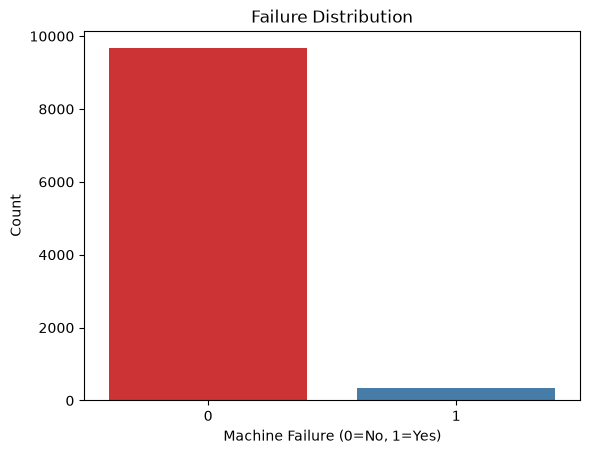

In [4]:
fig = plot_failure_distribution(df)

## 5. Product Type Distribution

Product types are unevenly split too — most machines are the low-quality (`L`) variant, matching the real-world scenario this dataset simulates (cheaper parts are more common).

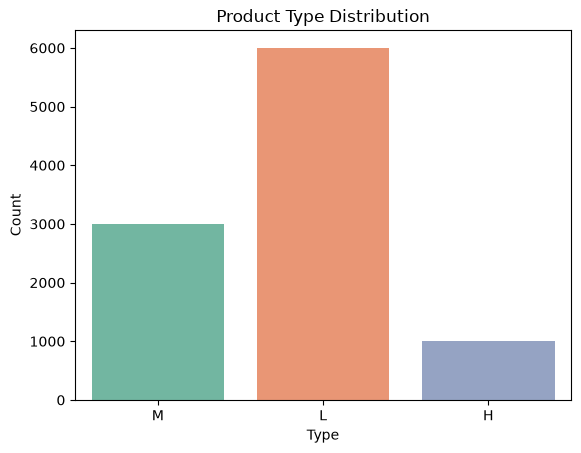

In [5]:
fig = plot_product_type_distribution(df)

## 6. Numerical Feature Distributions

All five numerical features are roughly normally distributed, with `Tool_Wear` skewing toward lower values (most machines are inspected/serviced before wear gets too high).

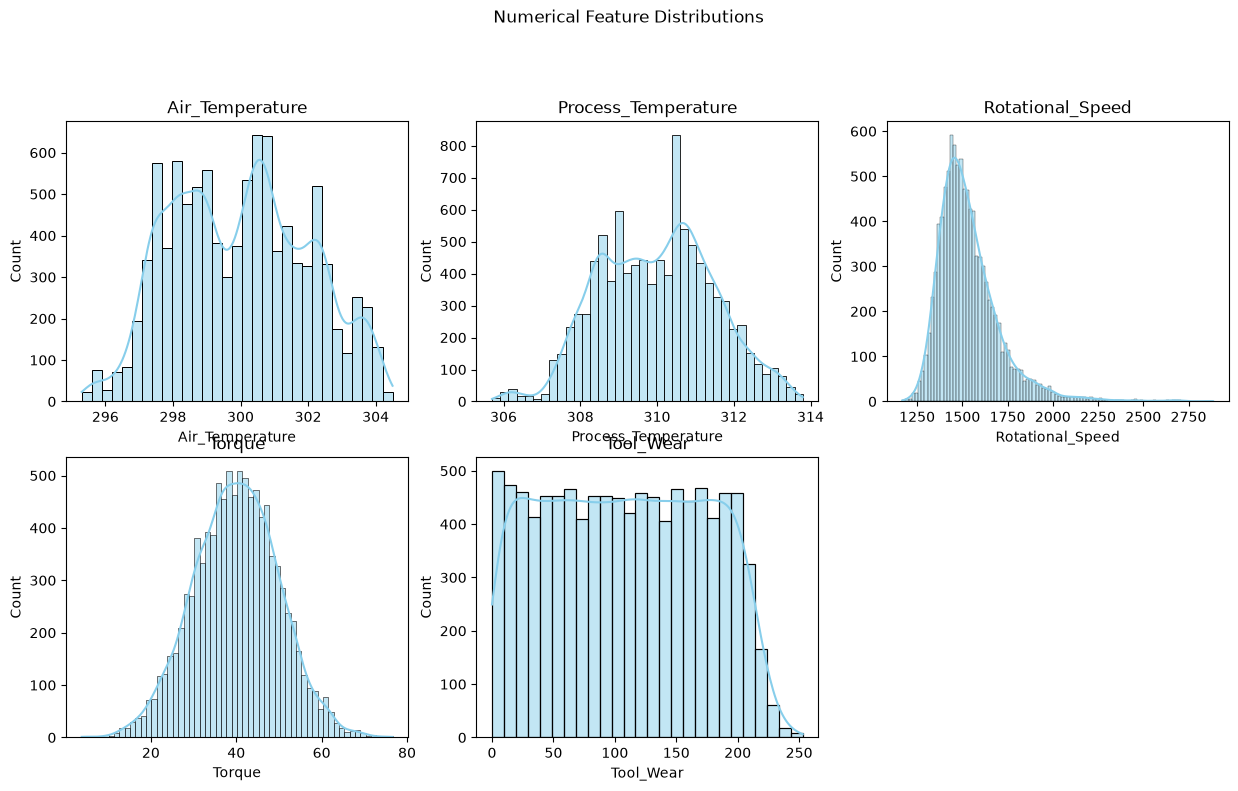

In [6]:
fig = plot_numerical_distributions(df)

## 7. Correlation Heatmap

`Air_Temperature` and `Process_Temperature` are strongly correlated (physically expected — the process runs hotter than ambient by a roughly fixed margin), and `Torque` and `Rotational_Speed` are mildly negatively correlated (higher speed, lower torque — consistent with constant-power operation).

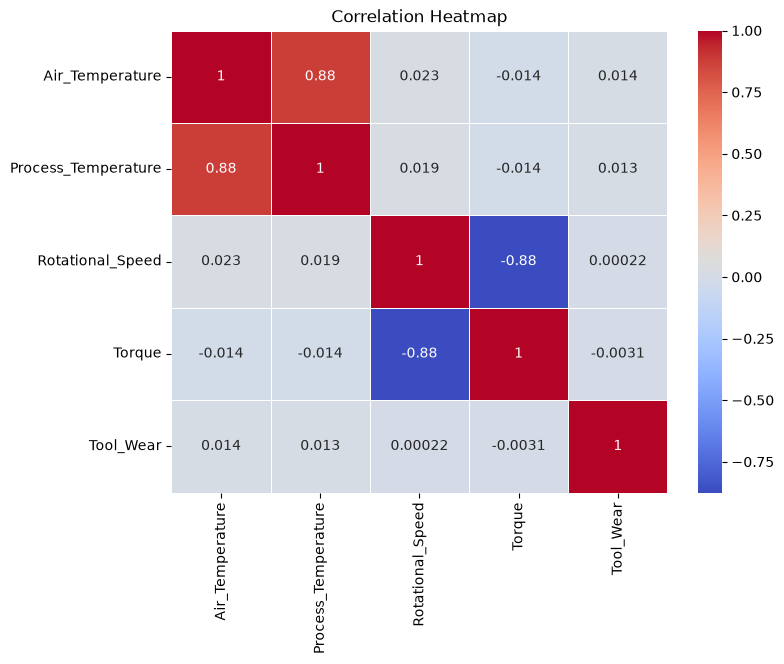

In [7]:
fig = plot_correlation_heatmap(df)

## 8. Numerical Features vs. Failure

Boxplots of each numerical feature, split by whether the machine failed. Failures cluster at higher `Torque` and higher `Tool_Wear` — both make physical sense (more mechanical stress, more wear before breakdown).

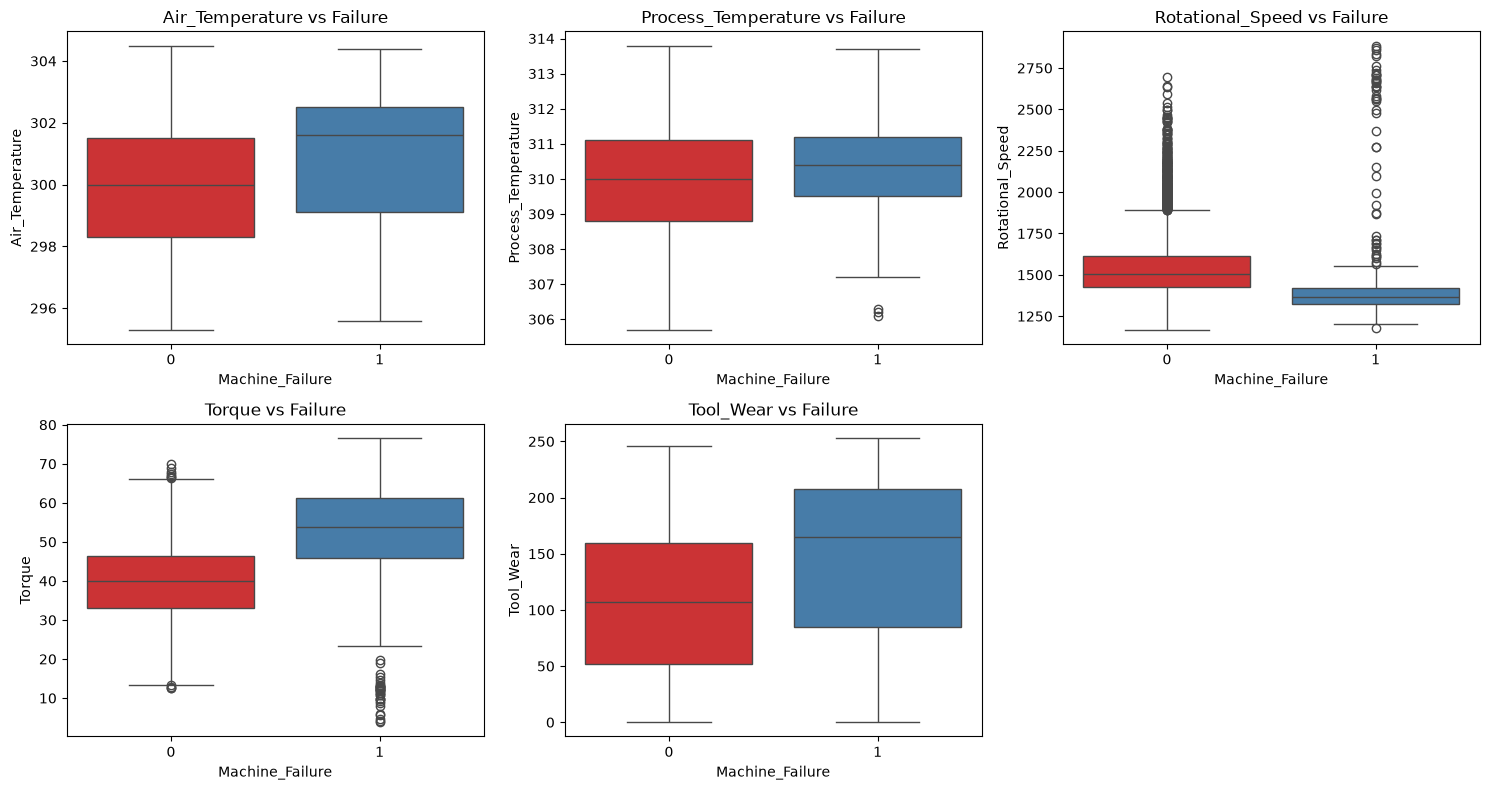

In [8]:
fig = plot_feature_vs_failure_boxplots(df)

## 9. Failure Rate by Product Type

Lower-quality (`L`) machines fail somewhat more often than higher-quality (`H`) ones — the dataset was designed with tighter tool-wear failure thresholds for cheaper parts.

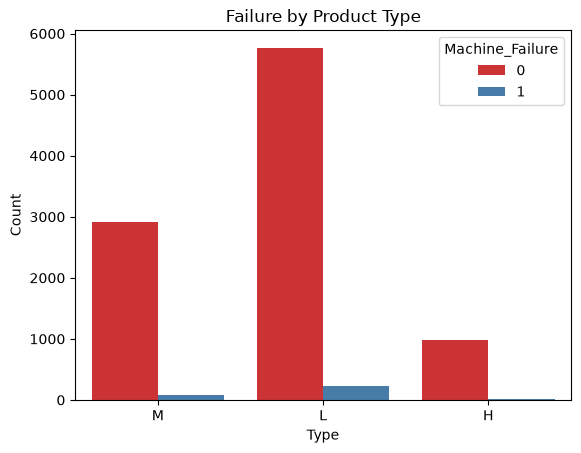

In [9]:
fig = plot_failure_by_product_type(df)

## 10. Feature Set and Train/Test Split

Finally, we assemble the modeling feature set — only the six approved features, explicitly excluding the leakage columns — and produce the stratified 80/20 train/test split used everywhere downstream.

In [10]:
X, y = get_features_and_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
print(f"Features used for modeling: {list(X.columns)}")
print(f"Train/test shapes: {X_train.shape} / {X_test.shape}")

2026-08-26 12:14:17,908 - src.data.preprocessing - INFO - X shape: (10000, 6), y shape: (10000,)


2026-08-26 12:14:17,910 - src.data.preprocessing - INFO - y distribution:
Machine_Failure
0    9661
1     339
Name: count, dtype: int64


2026-08-26 12:14:18,774 - src.data.preprocessing - INFO - Train shape: X=(8000, 6), y=(8000,)


2026-08-26 12:14:18,776 - src.data.preprocessing - INFO - Test shape: X=(2000, 6), y=(2000,)


Features used for modeling: ['Type', 'Air_Temperature', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear']
Train/test shapes: (8000, 6) / (2000, 6)


## Next Steps

Model training, baseline comparison, GridSearchCV tuning, and final evaluation live in `src/models/` and are chained together in `src/run_pipeline.py`. See the project README for:

- How to run the full pipeline (`python -m src.run_pipeline`)
- The results table (baseline comparison + tuned Random Forest)
- The **Limitations** section covering the recall / class-imbalance trade-off
- The **Scope note** on why GridSearchCV tuning was applied only to Random Forest